<a href="https://colab.research.google.com/github/cantika-alff/VisiKomputer-2025/blob/main/Jobsheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 2

## Praktikum D1 - Memulai Klasifikasi Gambar dengan Dataset Sederhana

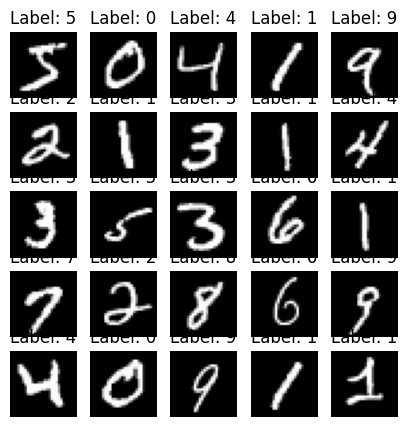

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25) :
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f'Label: {y_train[i]}')
  plt.axis('off')
plt.show()

## Praktikum D2 - Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


## Praktikum D3 – Membangun CNN Sederhana

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.8956 - loss: 0.3348 - val_accuracy: 0.9768 - val_loss: 0.0747
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 49s 29ms/step - accuracy: 0.9833 - loss: 0.0542 - val_accuracy: 0.9897 - val_loss: 0.0349
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9894 - loss: 0.0329 - val_accuracy: 0.9920 - val_loss: 0.0289
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 27ms/step - accuracy: 0.9920 - loss: 0.0246 - val_accuracy: 0.9878 - val_loss: 0.0409
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9883 - val_loss: 0.0389


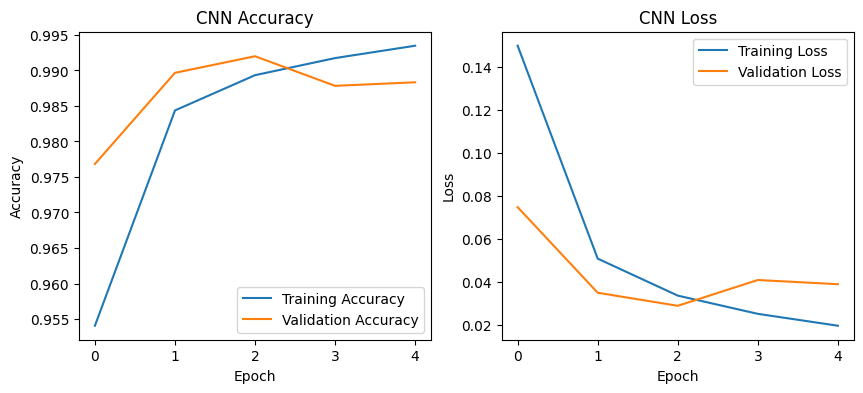

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Praktikum D4 – Eksperimen dengan Dataset Lebih Kompleks (CIFAR-10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.3841 - loss: 1.6856 - val_accuracy: 0.5840 - val_loss: 1.1806
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.5965 - loss: 1.1420 - val_accuracy: 0.6124 - val_loss: 1.1085
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.6568 - loss: 0.9835 - val_accuracy: 0.6682 - val_loss: 0.9586
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 44ms/step - accuracy: 0.6956 - loss: 0.8844 - val_accuracy: 0.6696 - val_loss: 0.9474
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 40ms/step - accuracy: 0.7214 - loss: 0.8071 - val_accuracy: 0.7040 - val_loss: 0.8695


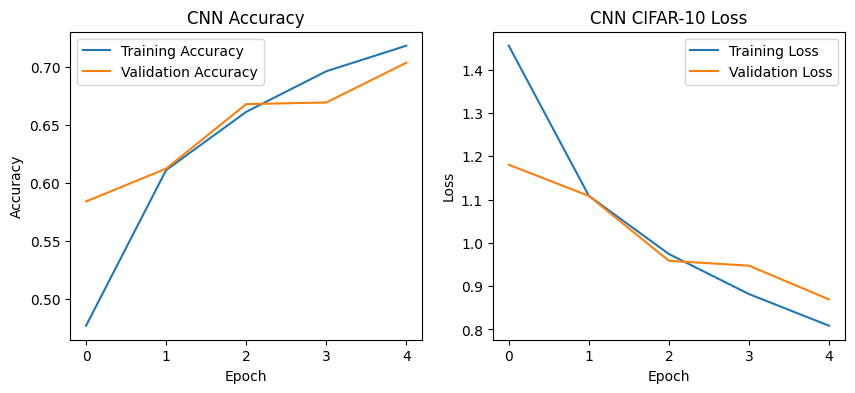

In [12]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0,5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot History =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Praktikum D5 – Transfer Learning dengan Model Pra-Latih

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 707s 500ms/step - accuracy: 0.5074 - loss: 1.4048 - val_accuracy: 0.6182 - val_loss: 1.0834
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 739s 498ms/step - accuracy: 0.6324 - loss: 1.0523 - val_accuracy: 0.6412 - val_loss: 1.0242
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 742s 498ms/step - accuracy: 0.6590 - loss: 0.9706 - val_accuracy: 0.6486 - val_loss: 0.9903
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 746s 501ms/step - accuracy: 0.6759 - loss: 0.9217 - val_accuracy: 0.6532 - val_loss: 0.9925
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 703s 500ms/step - accuracy: 0.6959 - loss: 0.8655 - val_accuracy: 0.6692 - val_loss: 0.9582


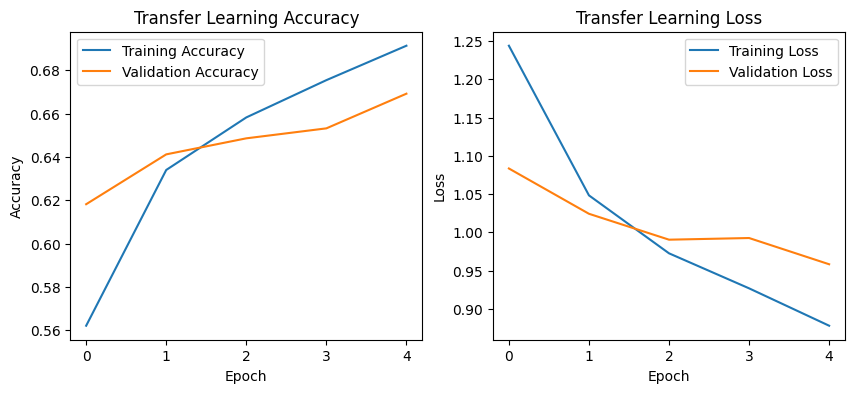

In [14]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

base_model.trainable = True

for layer in base_model.layers[:-2]:
  layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Praktikum D6 – Evaluasi dengan Confusion Matrix dan Metrik Lain

313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 389ms/step
              precision    recall  f1-score   support

           0       0.66      0.81      0.73      1000
           1       0.72      0.81      0.76      1000
           2       0.61      0.57      0.59      1000
           3       0.47      0.58      0.52      1000
           4       0.58      0.61      0.60      1000
           5       0.59      0.54      0.57      1000
           6       0.69      0.71      0.70      1000
           7       0.86      0.58      0.69      1000
           8       0.84      0.68      0.75      1000
           9       0.72      0.72      0.72      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000

Kelas yang paling sering salah diklasifikasikan: 5
Jumlah salah klasifikasi: 460


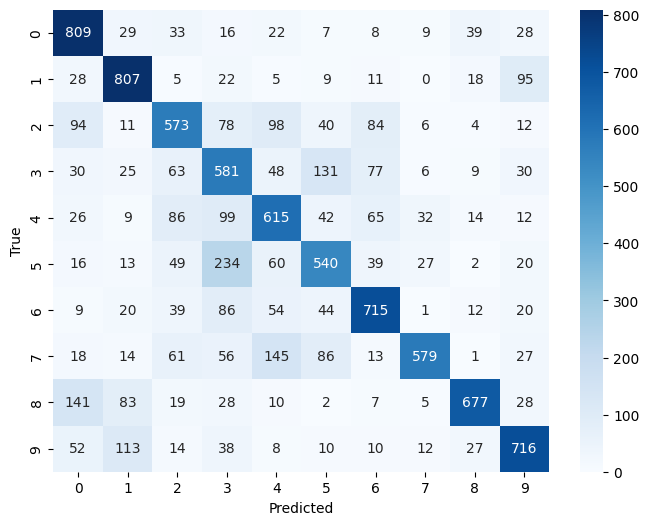

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

misclassified_counts = cm.sum(axis=1) - np.diag(cm)
worst_class = np.argmax(misclassified_counts)
print(f"Kelas yang paling sering salah diklasifikasikan: {worst_class}")
print(f"Jumlah salah klasifikasi: {misclassified_counts[worst_class]}")
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
